# KaroSpace — Usage Statistics

Data compiled from GitHub Traffic, Cloudflare Analytics, and bioRxiv metrics for the KaroSpace submission/cover letter.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib import rcParams

rcParams['figure.dpi'] = 150
rcParams['figure.facecolor'] = 'white'
rcParams['font.family'] = 'sans-serif'
rcParams['font.size'] = 10
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

In [15]:
# ── Data ──

# GitHub Traffic (last 14 days)
github = dict(clones=252, unique_cloners=95, views=91, unique_visitors=44)
github_referrers = pd.DataFrame({
    'site': ['github.com', 'biorxiv.org', 'Google'],
    'views': [30, 15, 6],
    'unique_visitors': [6, 3, 5],
})

# Cloudflare Analytics (30 days: 24 Mar – 23 Apr 2026)
cloudflare = dict(unique_visitors=1720, total_requests=26940,
                  data_served_gb=48, data_cached_gb=8)

# bioRxiv (March–April 2026)
biorxiv = dict(abstract=677, html=77, pdf=241,
               altmetric=6, x_posts=3, bluesky_posts=5)

In [16]:
# ── Style ──

PAL = {
    'cf':       '#F6821F',   # Cloudflare orange
    'cf_light': '#FBBF7A',
    'gh':       '#24292F',   # GitHub charcoal
    'gh_light': '#656D76',
    'bio':      '#AC2B37',   # bioRxiv red
    'bio_light':'#DA6A72',
    'bio_pale': '#EDA2A7',
    'x':        '#000000',   # X
    'bsky':     '#0085FF',   # Bluesky
    'google':   '#4285F4',
    'bg':       '#FAFAFA',
    'grid':     '#E5E5E5',
    'text':     '#333333',
    'muted':    '#888888',
}

def rounded_bar(ax, x, height, width=0.55, color='steelblue', radius=0.08, **kw):
    """Draw a bar with rounded top corners."""
    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch(
        (x - width/2, 0), width, height,
        boxstyle=f"round,pad=0,rounding_size={radius}",
        facecolor=color, edgecolor='none', **kw
    )
    ax.add_patch(box)
    return box

def annotate_bar(ax, x, val, fmt='{:,}', offset=0.03, fontsize=10):
    ymax = ax.get_ylim()[1]
    ax.text(x, val + ymax * offset, fmt.format(val),
            ha='center', va='bottom', fontsize=fontsize,
            fontweight='bold', color=PAL['text'])

## Main figure

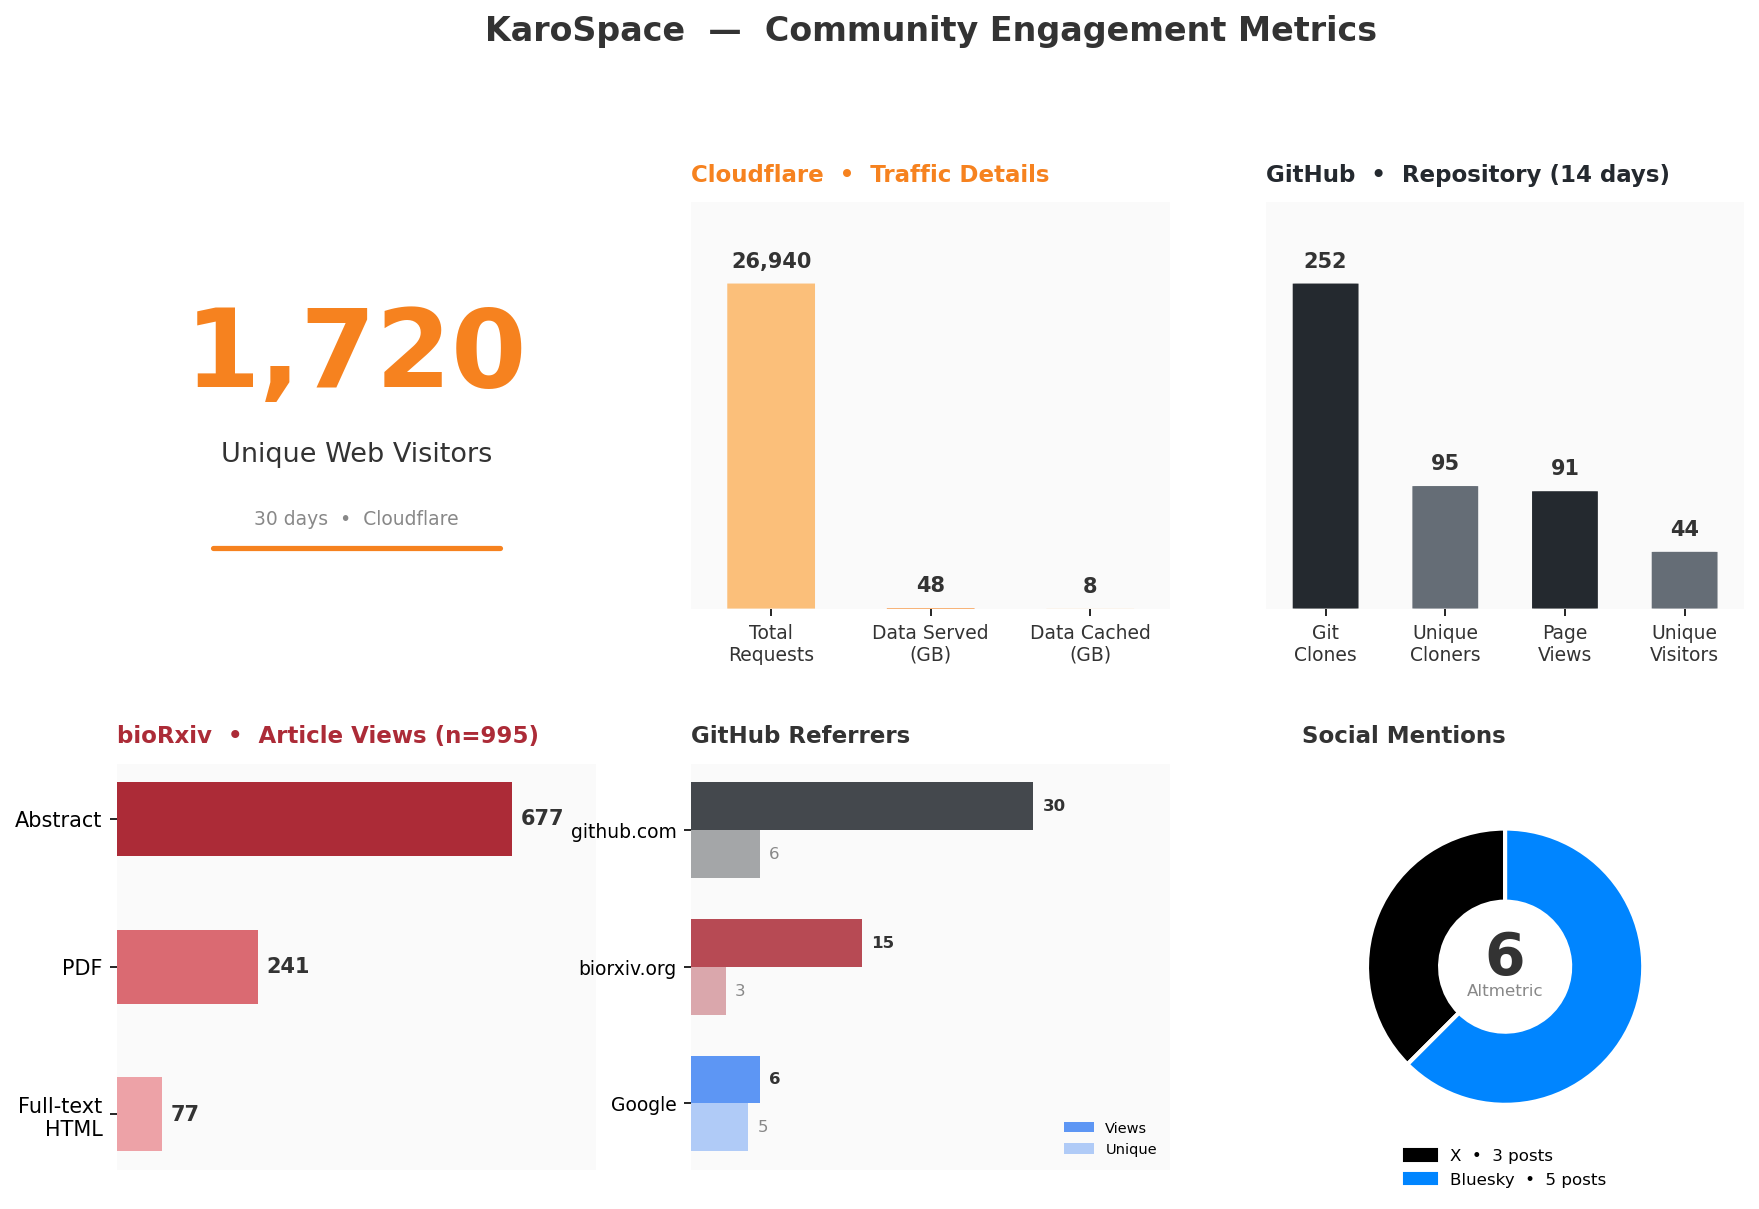

Saved PNG + PDF


In [17]:
fig = plt.figure(figsize=(14, 10), facecolor='white')
gs = GridSpec(3, 6, figure=fig, hspace=0.55, wspace=0.5,
              height_ratios=[0.08, 1, 1])

# ── Title row ──
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(0.5, 0.5, 'KaroSpace  —  Community Engagement Metrics',
              ha='center', va='center', fontsize=16, fontweight='bold',
              color=PAL['text'], transform=ax_title.transAxes)

# ═══════════════════════════════════════════════
# Row 1: Cloudflare hero (left) + Cloudflare details (mid) + GitHub (right)
# ═══════════════════════════════════════════════

# ── Cloudflare — Hero number ──
ax_hero = fig.add_subplot(gs[1, :2])
ax_hero.set_facecolor(PAL['bg'])
ax_hero.axis('off')
for spine in ax_hero.spines.values():
    spine.set_visible(False)

ax_hero.text(0.5, 0.62, f'{cloudflare["unique_visitors"]:,}',
             ha='center', va='center', fontsize=52, fontweight='bold',
             color=PAL['cf'], transform=ax_hero.transAxes)
ax_hero.text(0.5, 0.38, 'Unique Web Visitors',
             ha='center', va='center', fontsize=13, color=PAL['text'],
             transform=ax_hero.transAxes)
ax_hero.text(0.5, 0.22, '30 days  \u2022  Cloudflare',
             ha='center', va='center', fontsize=9, color=PAL['muted'],
             transform=ax_hero.transAxes)

# Orange accent line
ax_hero.plot([0.2, 0.8], [0.15, 0.15], color=PAL['cf'], lw=2.5,
             transform=ax_hero.transAxes, solid_capstyle='round')

# ── Cloudflare — Secondary metrics ──
ax_cf2 = fig.add_subplot(gs[1, 2:4])
ax_cf2.set_facecolor(PAL['bg'])

cf2_labels = ['Total\nRequests', 'Data Served\n(GB)', 'Data Cached\n(GB)']
cf2_vals   = [26940, 48, 8]
cf2_colors = [PAL['cf_light'], PAL['cf'], PAL['cf_light']]

ax_cf2.set_xlim(-0.5, len(cf2_vals)-0.5)
ax_cf2.set_ylim(0, max(cf2_vals)*1.25)
for i, (val, col) in enumerate(zip(cf2_vals, cf2_colors)):
    rounded_bar(ax_cf2, i, val, color=col, width=0.55)
    annotate_bar(ax_cf2, i, val)

ax_cf2.set_xticks(range(len(cf2_labels)))
ax_cf2.set_xticklabels(cf2_labels, fontsize=9, color=PAL['text'])
ax_cf2.set_yticks([])
ax_cf2.set_title('Cloudflare  \u2022  Traffic Details',
                 fontsize=11, fontweight='bold', color=PAL['cf'], pad=10, loc='left')
for spine in ax_cf2.spines.values():
    spine.set_visible(False)

# ── GitHub ──
ax_gh = fig.add_subplot(gs[1, 4:])
ax_gh.set_facecolor(PAL['bg'])

gh_labels = ['Git\nClones', 'Unique\nCloners', 'Page\nViews', 'Unique\nVisitors']
gh_vals   = [252, 95, 91, 44]
gh_colors = [PAL['gh'], PAL['gh_light'], PAL['gh'], PAL['gh_light']]

ax_gh.set_xlim(-0.5, len(gh_vals)-0.5)
ax_gh.set_ylim(0, max(gh_vals)*1.25)
for i, (val, col) in enumerate(zip(gh_vals, gh_colors)):
    rounded_bar(ax_gh, i, val, color=col, width=0.55)
    annotate_bar(ax_gh, i, val)

ax_gh.set_xticks(range(len(gh_labels)))
ax_gh.set_xticklabels(gh_labels, fontsize=9, color=PAL['text'])
ax_gh.set_yticks([])
ax_gh.set_title('GitHub  \u2022  Repository (14 days)',
                fontsize=11, fontweight='bold', color=PAL['gh'], pad=10, loc='left')
for spine in ax_gh.spines.values():
    spine.set_visible(False)

# ═══════════════════════════════════════════════
# Row 2: bioRxiv views (left) + Referrers (mid) + Social (right)
# ═══════════════════════════════════════════════

# ── bioRxiv views ──
ax_bio = fig.add_subplot(gs[2, :2])
ax_bio.set_facecolor(PAL['bg'])

bio_cats = ['Abstract', 'PDF', 'Full-text\nHTML']
bio_vals = [677, 241, 77]
bio_colors = [PAL['bio'], PAL['bio_light'], PAL['bio_pale']]

bars_bio = ax_bio.barh(bio_cats[::-1], bio_vals[::-1],
                       color=bio_colors[::-1], height=0.5, edgecolor='none',
                       zorder=3)

for bar, val in zip(bars_bio, bio_vals[::-1]):
    ax_bio.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
               f'{val:,}', ha='left', va='center', fontsize=10,
               fontweight='bold', color=PAL['text'])

ax_bio.set_xlim(0, 820)
ax_bio.set_title(f'bioRxiv  \u2022  Article Views (n={sum(bio_vals):,})',
                 fontsize=11, fontweight='bold', color=PAL['bio'], pad=10, loc='left')
ax_bio.xaxis.set_visible(False)
for spine in ax_bio.spines.values():
    spine.set_visible(False)

# ── Referrers ──
ax_ref = fig.add_subplot(gs[2, 2:4])
ax_ref.set_facecolor(PAL['bg'])

ref_labels = ['github.com', 'biorxiv.org', 'Google']
ref_views  = [30, 15, 6]
ref_unique = [6, 3, 5]
ref_colors = [PAL['gh'], PAL['bio'], PAL['google']]

y = np.arange(len(ref_labels))
h = 0.35
ax_ref.barh(y + h/2, ref_views[::-1], height=h, color=[c for c in ref_colors[::-1]],
            label='Views', edgecolor='none', alpha=0.85, zorder=3)
ax_ref.barh(y - h/2, ref_unique[::-1], height=h,
            color=[c for c in ref_colors[::-1]], alpha=0.4,
            label='Unique', edgecolor='none', zorder=3)

for i, (v, u) in enumerate(zip(ref_views[::-1], ref_unique[::-1])):
    ax_ref.text(v + 0.8, i + h/2, str(v), va='center', fontsize=8, fontweight='bold', color=PAL['text'])
    ax_ref.text(u + 0.8, i - h/2, str(u), va='center', fontsize=8, color=PAL['muted'])

ax_ref.set_yticks(y)
ax_ref.set_yticklabels(ref_labels[::-1], fontsize=9)
ax_ref.set_xlim(0, 42)
ax_ref.set_title('GitHub Referrers',
                 fontsize=11, fontweight='bold', color=PAL['text'], pad=10, loc='left')
ax_ref.legend(fontsize=7, frameon=False, loc='lower right')
ax_ref.xaxis.set_visible(False)
for spine in ax_ref.spines.values():
    spine.set_visible(False)

# ── Social / Altmetric ──
ax_soc = fig.add_subplot(gs[2, 4:])
ax_soc.set_facecolor(PAL['bg'])

social_data = [biorxiv['x_posts'], biorxiv['bluesky_posts']]
social_colors = [PAL['x'], PAL['bsky']]

wedges, texts = ax_soc.pie(
    social_data, colors=social_colors, startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    radius=0.85, center=(0.5, 0.5)
)

ax_soc.text(0.5, 0.55, str(biorxiv['altmetric']), ha='center', va='center',
            fontsize=28, fontweight='bold', color=PAL['text'])
ax_soc.text(0.5, 0.35, 'Altmetric', ha='center', va='center',
            fontsize=8, color=PAL['muted'])

legend_items = [
    mpatches.Patch(color=PAL['x'], label=f'X  \u2022  {biorxiv["x_posts"]} posts'),
    mpatches.Patch(color=PAL['bsky'], label=f'Bluesky  \u2022  {biorxiv["bluesky_posts"]} posts'),
]
ax_soc.legend(handles=legend_items, loc='lower center', fontsize=8,
              frameon=False, bbox_to_anchor=(0.5, -0.08))
ax_soc.set_title('Social Mentions',
                 fontsize=11, fontweight='bold', color=PAL['text'], pad=10, loc='left')
ax_soc.set_aspect('equal')

plt.savefig('../data/karospace_usage_stats.png', bbox_inches='tight', dpi=250, facecolor='white')
plt.savefig('../data/karospace_usage_stats.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved PNG + PDF")

## Cover letter text

In [18]:
total_bio = biorxiv['abstract'] + biorxiv['html'] + biorxiv['pdf']

print("Suggested cover letter paragraph:")
print()
print(f'"Since posting the preprint, KaroSpace has attracted substantial community')
print(f'interest: the web application received {cloudflare["unique_visitors"]:,} unique visitors')
print(f'and served {cloudflare["data_served_gb"]} GB of data over 30 days, the GitHub repository')
print(f'was cloned {github["clones"]} times by {github["unique_cloners"]} unique users in the')
print(f'last 14 days alone, and the bioRxiv preprint accumulated {total_bio:,} views')
print(f'with {biorxiv["pdf"]} PDF downloads across March\u2013April 2026."')

Suggested cover letter paragraph:

"Since posting the preprint, KaroSpace has attracted substantial community
interest: the web application received 1,720 unique visitors
and served 48 GB of data over 30 days, the GitHub repository
was cloned 252 times by 95 unique users in the
last 14 days alone, and the bioRxiv preprint accumulated 995 views
with 241 PDF downloads across March–April 2026."
